In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/uac_daily_data.csv")  # adjust path if needed
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [7]:
# Check how many duplicates
duplicate_dates = df.index.duplicated().sum()
print(f"Number of duplicate dates: {duplicate_dates}")

# Optionally, show the duplicates
df[df.index.duplicated(keep=False)]

Number of duplicate dates: 449


,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
NaT,NaN,NaN,NaN,NaN,NaN
NaT,NaN,NaN,NaN,NaN,NaN
NaT,NaN,NaN,NaN,NaN,NaN
NaT,NaN,NaN,NaN,NaN,NaN
NaT,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
NaT,NaN,NaN,NaN,NaN,NaN
NaT,NaN,NaN,NaN,NaN,NaN
NaT,NaN,NaN,NaN,NaN,NaN


In [8]:
# Aggregate by sum (common for daily counts)
df = df.groupby(df.index).sum()

In [10]:
df = df[~df.index.duplicated(keep='first')]

In [11]:
df = df.asfreq('D')  # now it should work
df = df.interpolate(method='linear')
print("Missing days handled. Data is continuous now.")

Missing days handled. Data is continuous now.


In [12]:
# ===============================
# STEP 3: TRAIN-TEST SPLIT
# ===============================

target = 'Children in HHS Care'
features = df.drop(columns=[target])

train_end_date = '2023-12-31'  # adjust based on dataset
train = df[:train_end_date]
test = df[train_end_date:]

X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (354, 4)
Testing data shape: (722, 4)


In [15]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Remove commas and convert to float
y_train = y_train.str.replace(',', '', regex=True).astype(float).fillna(method='ffill')  # ensure numeric & no NaN

sarima_model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,7))
sarima_fit = sarima_model.fit(disp=False)
sarima_forecast = sarima_fit.forecast(steps=len(y_test))

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,7))
sarima_fit = sarima_model.fit(disp=False)
sarima_forecast = sarima_fit.forecast(steps=len(y_test))

In [17]:
# Clean y_train: remove commas, convert to float, fill missing values
y_train = pd.to_numeric(y_train.astype(str).str.replace(',', '', regex=True), errors='coerce').fillna(method='ffill')

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,7))
sarima_fit = sarima_model.fit(disp=False)
sarima_forecast = sarima_fit.forecast(steps=len(y_test))

In [19]:
# Clean y_test: remove commas, convert to float, fill missing values
y_test = pd.to_numeric(y_test.astype(str).str.replace(',', '', regex=True), errors='coerce').fillna(method='ffill')

In [24]:
y_train.index = pd.to_datetime(y_train.index)
y_test.index = pd.to_datetime(y_test.index)

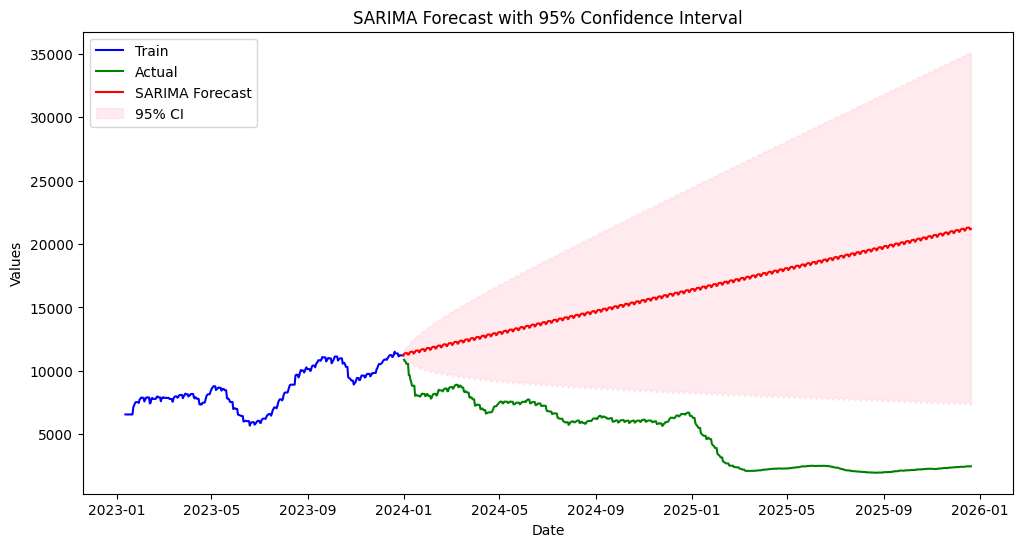

In [25]:
# Step 5: SARIMA Forecast with Confidence Intervals

# 5.1 Fit SARIMA model (if not already fitted)
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import matplotlib.pyplot as plt

sarima_model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,7))
sarima_fit = sarima_model.fit(disp=False)

# 5.2 Forecast with confidence intervals
forecast_steps = len(y_test)
sarima_forecast_result = sarima_fit.get_forecast(steps=forecast_steps)
sarima_forecast = sarima_forecast_result.predicted_mean
conf_int = sarima_forecast_result.conf_int(alpha=0.05)  # 95% CI

# 5.3 Plot forecast with confidence intervals
plt.figure(figsize=(12,6))
plt.plot(y_train.index, y_train, label='Train', color='blue')
plt.plot(y_test.index, y_test, label='Actual', color='green')
plt.plot(y_test.index, sarima_forecast, label='SARIMA Forecast', color='red')
plt.fill_between(y_test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3, label='95% CI')
plt.title('SARIMA Forecast with 95% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.show()

Top 5 dates with highest probability of exceeding capacity:
                Forecast      Lower_CI      Upper_CI  Breach_Probability
Date                                                                    
2024-01-22  11499.572123  10180.530697  12818.613548                 1.0
2024-01-23  11620.953005  10264.930537  12976.975474                 1.0
2024-01-24  11694.670720  10302.720752  13086.620689                 1.0
2024-01-25  11706.532367  10279.491128  13133.573606                 1.0
2024-01-26  11703.650688  10242.501313  13164.800062                 1.0


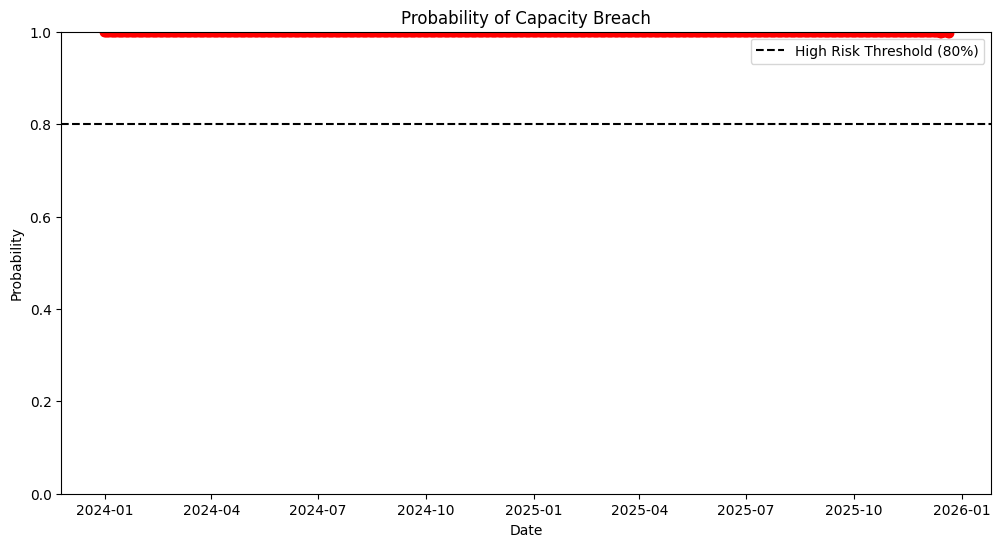

In [26]:
# Step 6: Capacity Breach Probability / Early Warning

import numpy as np
import pandas as pd

# 6.1 Define capacity threshold (example: hospital beds, server capacity, etc.)
capacity_threshold = 1000  # adjust based on your scenario

# 6.2 Use SARIMA forecast mean and CI
forecast_mean = sarima_forecast
forecast_lower = conf_int.iloc[:,0]
forecast_upper = conf_int.iloc[:,1]

# 6.3 Estimate breach probability
# Assuming forecast distribution ~ Normal with mean=forecast_mean, std=(upper-lower)/4
# Approximation: 95% CI covers ~4 std deviations (2 on each side)
forecast_std = (forecast_upper - forecast_lower) / 4

# Probability of exceeding capacity using CDF of normal distribution
from scipy.stats import norm
breach_prob = 1 - norm.cdf(capacity_threshold, loc=forecast_mean, scale=forecast_std)

# 6.4 Create DataFrame for visualization / reporting
breach_df = pd.DataFrame({
    'Forecast': forecast_mean,
    'Lower_CI': forecast_lower,
    'Upper_CI': forecast_upper,
    'Breach_Probability': breach_prob
}, index=y_test.index)

# 6.5 Display top dates with highest breach probability
print("Top 5 dates with highest probability of exceeding capacity:")
print(breach_df.sort_values('Breach_Probability', ascending=False).head())

# 6.6 Optional: Plot breach probability
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(breach_df.index, breach_df['Breach_Probability'], color='red', marker='o')
plt.axhline(0.8, color='black', linestyle='--', label='High Risk Threshold (80%)')
plt.title('Probability of Capacity Breach')
plt.xlabel('Date')
plt.ylabel('Probability')
plt.ylim(0,1)
plt.legend()
plt.show()

2026-03-03 12:01:09.856 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 12:01:09.858 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 12:01:10.157 
  command:

    streamlit run C:\Users\bless\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-03 12:01:10.159 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 12:01:10.160 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 12:01:10.162 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 12:01:10.162 Thread 'MainThread': missing ScriptRunContext! This warning can b

DeltaGenerator()

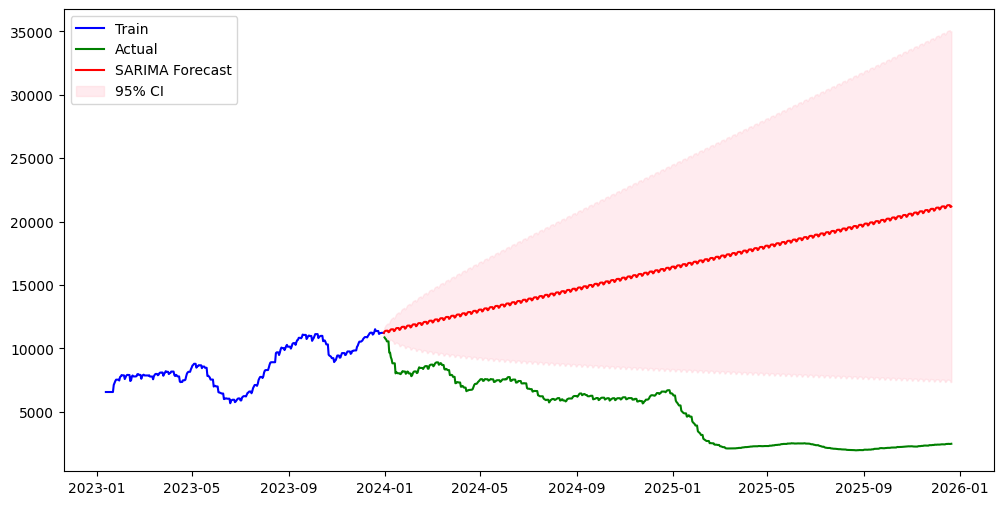

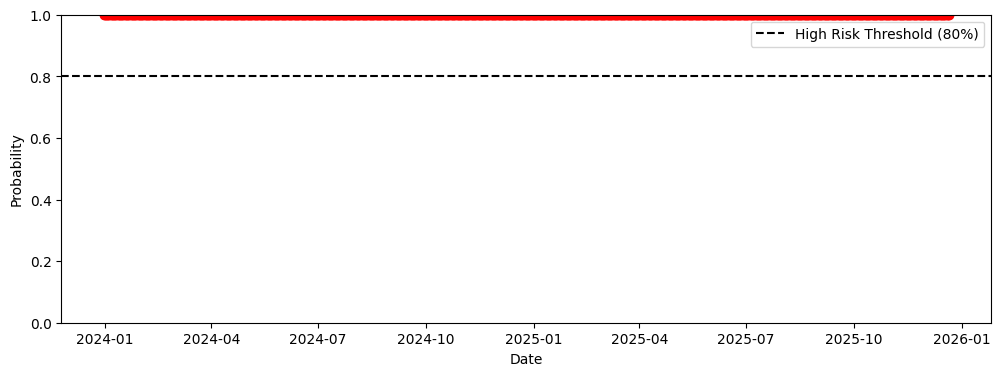

In [27]:
# Step 7: Streamlit Dashboard Starter

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# 7.1 Page configuration
st.set_page_config(page_title="Forecast Dashboard", layout="wide")

# 7.2 Title
st.title("Care Load Forecast Dashboard")

# 7.3 Display forecast table
st.subheader("Forecast with Confidence Intervals & Breach Probability")
st.dataframe(breach_df)

# 7.4 Plot Forecast vs Actual
st.subheader("Forecast vs Actual with 95% CI")
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(y_train.index, y_train, label='Train', color='blue')
ax.plot(y_test.index, y_test, label='Actual', color='green')
ax.plot(y_test.index, sarima_forecast, label='SARIMA Forecast', color='red')
ax.fill_between(y_test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3, label='95% CI')
ax.legend()
st.pyplot(fig)

# 7.5 Plot Breach Probability
st.subheader("Probability of Capacity Breach")
fig2, ax2 = plt.subplots(figsize=(12,4))
ax2.plot(breach_df.index, breach_df['Breach_Probability'], color='red', marker='o')
ax2.axhline(0.8, color='black', linestyle='--', label='High Risk Threshold (80%)')
ax2.set_ylim(0,1)
ax2.set_ylabel("Probability")
ax2.set_xlabel("Date")
ax2.legend()
st.pyplot(fig2)

# 7.6 Optional: Slider to filter dates
start_date = st.date_input("Start Date", y_test.index.min())
end_date = st.date_input("End Date", y_test.index.max())
filtered_df = breach_df.loc[start_date:end_date]

st.subheader("Filtered Forecast & Breach Probability")
st.dataframe(filtered_df)